# <font color=blue> 기계학습 기초: 회귀분석 실습 + GridSearchCV</font>
## Genome-to-Field 옥수수 수량 예측

기존 Linear Regression 실습 흐름에 하이퍼파라미터 최적화와 모델별 성능 비교를 추가한 버전이다.


In [1]:
import os
import re
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import sklearn.linear_model as lm
import sklearn.model_selection as mod_sel
import sklearn.metrics as met

from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

sns.set(style='whitegrid', context='notebook')
pd.set_option('display.max_columns', 120)

## 1. 데이터 불러오기

사용할 파일

- `g2f_2014_hybrid_data_clean.csv`: hybrid별 생육/수량 측정값
- `g2f_2014_weather.csv`: 재배지별 시간 단위 날씨 관측값

목표값은 `Grain Yield [bu/A]`이다.


In [2]:
DATA_DIR = 'G2F_2014'

hybrid_path = os.path.join(DATA_DIR, 'g2f_2014_hybrid_data_clean.csv')
weather_path = os.path.join(DATA_DIR, 'g2f_2014_weather.csv')

hybrid = pd.read_csv(hybrid_path)
weather = pd.read_csv(weather_path)

print('hybrid shape:', hybrid.shape)
print('weather shape:', weather.shape)
display(hybrid.head())

hybrid shape: (12675, 38)
weather shape: (207004, 24)


,Year,Field-Location,RecId,Source,Pedigree,Replicate,Block,Plot,Range,Pass,"LOCAL_CHECK (Yes, No[Blank])",Plot Length Field,Alley Length,Row Spacing,Plot Area,Rows/Plot,Packet/Plot,Kernels/Packet,# Seed,Date Planted,Date Harvested,Anthesis [date],Silking [date],Pollen DAP [days],Silk DAP [days],Plant Height [cm],Ear Height [cm],Stand Count [plants],Root Lodging [plants],Stalk Lodging [plants],Grain Moisture [%],Test Weight [lbs/bu],Plot Weight [lbs],Grain Yield [bu/A],"Plot Discarded [enter ""yes"" or ""blank""]",Comments,"Filler [enter ""filler"" or ""blank""]",[add additional measurements here]
0,2014,TXH1,2218825,LOCAL_CHECK,DEKALB 64-69,2,5,113,14.0,25.0,Yes,25.0,4,30,105.0,NaN,NaN,NaN,47.0,3/1/14,8/21/14,5/23/14,5/22/14,83.0,82.0,193.0,94.0,92.0,NaN,NaN,11.8,58.9,32.54,251.616994,NaN,NaN,NaN,NaN
1,2014,MNH1,2235804,13WJWE:CG102:1227,PHN11_LH145_0002/CG102,2,1,42,9.0,21.0,NaN,28.0,6,30,110.0,NaN,NaN,NaN,40.0,5/16/14,10/16/14,7/20/14,7/23/14,65.0,68.0,190.0,86.0,92.0,0.0,0.0,30.5,52.5,30.51,177.450596,NaN,NaN,NaN,NaN
2,2014,TXH1,2218560,WE13-80ISO-227-X-POL-80,MOG_NC230-043-1-1-1-1-B/PB80,1,5,98,6.0,30.0,NaN,25.0,4,30,105.0,NaN,NaN,NaN,47.0,3/1/14,8/21/14,5/25/14,5/25/14,85.0,85.0,211.0,127.0,89.0,NaN,NaN,11.7,60.3,16.28,126.028550,NaN,NaN,NaN,NaN
3,2014,TXH1,2218682,13SAJL:NURSE:0145,PHG39/PHN82,2,3,50,12.0,32.0,NaN,25.0,4,30,105.0,NaN,NaN,NaN,47.0,3/1/14,8/21/14,5/21/14,5/22/14,81.0,82.0,196.0,91.0,88.0,NaN,NaN,12.4,57.5,24.63,189.156972,NaN,NaN,NaN,NaN
4,2014,TXH1,2218600,WE13-195ISO-149-X-POL-195,TX303/LH195,1,10,258,11.0,25.0,NaN,25.0,4,30,105.0,NaN,NaN,NaN,47.0,3/1/14,8/21/14,5/27/14,5/28/14,87.0,88.0,213.0,107.0,87.0,NaN,NaN,12.9,57.6,26.91,205.487632,NaN,NaN,NaN,NaN


In [3]:
print('Hybrid columns')
display(pd.DataFrame({'column': hybrid.columns}))

print('Weather columns')
display(pd.DataFrame({'column': weather.columns}))

Hybrid columns


,column
0,Year
1,Field-Location
2,RecId
3,Source
4,Pedigree
5,Replicate
6,Block
7,Plot
8,Range
9,Pass


Weather columns


,column
0,Record Number
1,Field Location
2,Station ID
3,NWS Network
4,NWS Station
5,Day [Local]
6,Month [Local]
7,Year [Local]
8,Day of Year [Local]
9,Time [Local]


## 2. 목표값 확인

`Grain Yield [bu/A]`는 acre당 bushel 단위의 곡물 수량이다. 회귀분석에서는 이 값을 연속형 목표값으로 사용한다.


count    12087.000000
mean       148.471406
std         46.030295
min          9.217824
25%        119.381768
50%        152.567216
75%        179.881075
max        344.631088
Name: Grain Yield [bu/A], dtype: float64


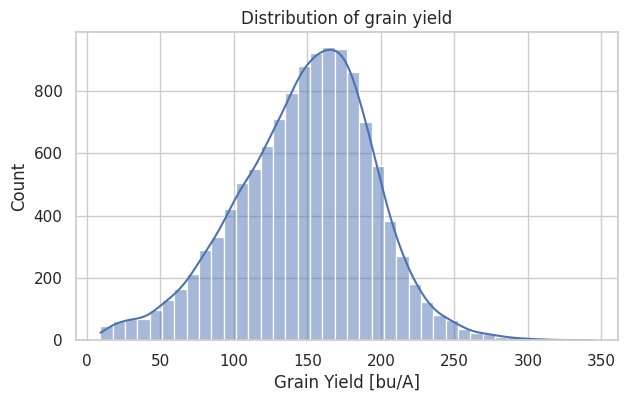

In [4]:
target_col = 'Grain Yield [bu/A]'

print(hybrid[target_col].describe())

plt.figure(figsize=(7, 4))
sns.histplot(hybrid[target_col], bins=40, kde=True)
plt.xlabel(target_col)
plt.title('Distribution of grain yield')
plt.show()

## 3. 기본 전처리

분석에서 제외할 행

- 목표값이 없는 행
- filler plot
- discarded plot

날짜형 컬럼은 `datetime`으로 변환하고, 파종-수확 기간과 개화 관련 feature를 만든다.


In [5]:
df = hybrid.copy()

# Remove rows without target values.
df = df[df[target_col].notna()].copy()

# Remove filler/discarded plots when the information is available.
filler_col = 'Filler [enter "filler" or "blank"]'
discard_col = 'Plot Discarded [enter "yes" or "blank"]'

if filler_col in df.columns:
    df = df[df[filler_col].fillna('').str.lower().ne('filler')].copy()

if discard_col in df.columns:
    df = df[df[discard_col].fillna('').str.lower().ne('yes')].copy()

# Date parsing.
date_cols = ['Date Planted', 'Date Harvested', 'Anthesis [date]', 'Silking [date]']
for col in date_cols:
    df[col] = pd.to_datetime(df[col], format='%m/%d/%y', errors='coerce')

df['Growing Season [days]'] = (df['Date Harvested'] - df['Date Planted']).dt.days
df['Anthesis DAP from date'] = (df['Anthesis [date]'] - df['Date Planted']).dt.days
df['Silking DAP from date'] = (df['Silking [date]'] - df['Date Planted']).dt.days

def location_key(value):
    """Map names such as IAH1a and 'IAH1 IAI1' to a common hybrid-location key."""
    if pd.isna(value):
        return np.nan
    text = str(value).strip()
    match = re.match(r'([A-Z]+H\d+)', text)
    return match.group(1) if match else text.split()[0]

df['LocationKey'] = df['Field-Location'].apply(location_key)

print('clean hybrid shape:', df.shape)
print('number of locations:', df['Field-Location'].nunique())
display(df[[target_col, 'Field-Location', 'LocationKey', 'Pedigree', 'Date Planted', 'Date Harvested', 'Growing Season [days]']].head())

clean hybrid shape: (12087, 42)
number of locations: 24


,Grain Yield [bu/A],Field-Location,LocationKey,Pedigree,Date Planted,Date Harvested,Growing Season [days]
0,251.616994,TXH1,TXH1,DEKALB 64-69,2014-03-01,2014-08-21,173
1,177.450596,MNH1,MNH1,PHN11_LH145_0002/CG102,2014-05-16,2014-10-16,153
2,126.028550,TXH1,TXH1,MOG_NC230-043-1-1-1-1-B/PB80,2014-03-01,2014-08-21,173
3,189.156972,TXH1,TXH1,PHG39/PHN82,2014-03-01,2014-08-21,173
4,205.487632,TXH1,TXH1,TX303/LH195,2014-03-01,2014-08-21,173


## 4. 날씨 데이터 요약 feature 만들기

시간 단위 날씨 데이터를 그대로 모델에 넣기는 어렵다. 여기서는 재배지별로 아래와 같은 요약 통계를 만든다.

- 평균/최고/최저 기온
- 누적 강수량
- 평균 상대습도
- 평균 일사량
- 평균 풍속
- 관측 일수

더 정교한 분석에서는 파종일부터 수확일까지의 기간만 사용하거나, 생육 단계별로 0-30일, 30-60일처럼 나누어 요약할 수 있다.


In [6]:
weather_df = weather.copy()
weather_df['LocationKey'] = weather_df['Field Location'].apply(location_key)

weather_features = (
    weather_df
    .groupby('LocationKey')
    .agg(
        weather_temp_mean=('Temperature [C]', 'mean'),
        weather_temp_max=('Temperature [C]', 'max'),
        weather_temp_min=('Temperature [C]', 'min'),
        weather_rain_sum=('Rainfall [mm]', 'sum'),
        weather_rh_mean=('Relative Humidity [%]', 'mean'),
        weather_solar_mean=('Solar Radiation [W/m2]', 'mean'),
        weather_wind_mean=('Wind Speed [m/s]', 'mean'),
        weather_records=('Record Number', 'count'),
        weather_days=('Day of Year [Local]', 'nunique'),
    )
    .reset_index()
)

print('weather feature shape:', weather_features.shape)
display(weather_features.head())

weather feature shape: (30, 10)


,LocationKey,weather_temp_mean,weather_temp_max,weather_temp_min,weather_rain_sum,weather_rh_mean,weather_solar_mean,weather_wind_mean,weather_records,weather_days
0,DEH1,21.831401,36.83,5.78,176.022,75.171968,232.197522,0.407793,6860,144
1,DEI1,21.448867,35.17,2.28,133.604,70.308234,228.791471,0.413252,7104,148
2,GAH1,24.764605,40.20,3.60,827.400,74.841693,182.237230,0.602320,7728,161
3,GAI2,25.230347,38.70,8.60,684.700,72.069811,276.796087,0.805282,6288,131
4,IAH1,19.026296,33.89,-0.61,747.268,74.709283,211.567453,0.784737,7584,158


In [7]:
weather_features

,LocationKey,weather_temp_mean,weather_temp_max,weather_temp_min,weather_rain_sum,weather_rh_mean,weather_solar_mean,weather_wind_mean,weather_records,weather_days
0,DEH1,21.831401,36.83,5.78,176.022,75.171968,232.197522,0.407793,6860,144
1,DEI1,21.448867,35.17,2.28,133.604,70.308234,228.791471,0.413252,7104,148
2,GAH1,24.764605,40.20,3.60,827.400,74.841693,182.237230,0.602320,7728,161
3,GAI2,25.230347,38.70,8.60,684.700,72.069811,276.796087,0.805282,6288,131
4,IAH1,19.026296,33.89,-0.61,747.268,74.709283,211.567453,0.784737,7584,158
5,IAH2,18.806461,32.33,-0.67,617.728,76.722607,168.456949,0.879096,7835,164
6,IAH3,18.572108,34.11,-2.50,587.248,76.584246,205.080376,0.904863,7776,162
7,IAH4,19.443127,34.61,-0.17,535.940,74.766214,212.524096,0.801088,7808,163
8,IAI2,20.419564,36.60,1.50,678.180,76.531535,225.073408,1.478526,6285,132
9,IAI3,19.231351,33.44,-0.67,554.736,73.318462,NaN,0.889035,7276,152


In [8]:
df_ml = df.merge(weather_features, on='LocationKey', how='left')

print('modeling data shape:', df_ml.shape)
print('weather matched rows:', df_ml['weather_temp_mean'].notna().sum(), '/', len(df_ml))
display(df_ml.head())

modeling data shape: (12087, 51)
weather matched rows: 12087 / 12087


,Year,Field-Location,RecId,Source,Pedigree,Replicate,Block,Plot,Range,Pass,"LOCAL_CHECK (Yes, No[Blank])",Plot Length Field,Alley Length,Row Spacing,Plot Area,Rows/Plot,Packet/Plot,Kernels/Packet,# Seed,Date Planted,Date Harvested,Anthesis [date],Silking [date],Pollen DAP [days],Silk DAP [days],Plant Height [cm],Ear Height [cm],Stand Count [plants],Root Lodging [plants],Stalk Lodging [plants],Grain Moisture [%],Test Weight [lbs/bu],Plot Weight [lbs],Grain Yield [bu/A],"Plot Discarded [enter ""yes"" or ""blank""]",Comments,"Filler [enter ""filler"" or ""blank""]",[add additional measurements here],Growing Season [days],Anthesis DAP from date,Silking DAP from date,LocationKey,weather_temp_mean,weather_temp_max,weather_temp_min,weather_rain_sum,weather_rh_mean,weather_solar_mean,weather_wind_mean,weather_records,weather_days
0,2014,TXH1,2218825,LOCAL_CHECK,DEKALB 64-69,2,5,113,14.0,25.0,Yes,25.0,4,30,105.0,NaN,NaN,NaN,47.0,2014-03-01,2014-08-21,2014-05-23,2014-05-22,83.0,82.0,193.0,94.0,92.0,NaN,NaN,11.8,58.9,32.54,251.616994,NaN,NaN,NaN,NaN,173,83.0,82.0,TXH1,25.269983,38.61,2.83,471.678,72.827893,267.389818,1.831879,6888,144
1,2014,MNH1,2235804,13WJWE:CG102:1227,PHN11_LH145_0002/CG102,2,1,42,9.0,21.0,NaN,28.0,6,30,110.0,NaN,NaN,NaN,40.0,2014-05-16,2014-10-16,2014-07-20,2014-07-23,65.0,68.0,190.0,86.0,92.0,0.0,0.0,30.5,52.5,30.51,177.450596,NaN,NaN,NaN,NaN,153,65.0,68.0,MNH1,18.476343,32.78,-4.22,521.716,73.524031,220.389368,1.751564,7299,153
2,2014,TXH1,2218560,WE13-80ISO-227-X-POL-80,MOG_NC230-043-1-1-1-1-B/PB80,1,5,98,6.0,30.0,NaN,25.0,4,30,105.0,NaN,NaN,NaN,47.0,2014-03-01,2014-08-21,2014-05-25,2014-05-25,85.0,85.0,211.0,127.0,89.0,NaN,NaN,11.7,60.3,16.28,126.028550,NaN,NaN,NaN,NaN,173,85.0,85.0,TXH1,25.269983,38.61,2.83,471.678,72.827893,267.389818,1.831879,6888,144
3,2014,TXH1,2218682,13SAJL:NURSE:0145,PHG39/PHN82,2,3,50,12.0,32.0,NaN,25.0,4,30,105.0,NaN,NaN,NaN,47.0,2014-03-01,2014-08-21,2014-05-21,2014-05-22,81.0,82.0,196.0,91.0,88.0,NaN,NaN,12.4,57.5,24.63,189.156972,NaN,NaN,NaN,NaN,173,81.0,82.0,TXH1,25.269983,38.61,2.83,471.678,72.827893,267.389818,1.831879,6888,144
4,2014,TXH1,2218600,WE13-195ISO-149-X-POL-195,TX303/LH195,1,10,258,11.0,25.0,NaN,25.0,4,30,105.0,NaN,NaN,NaN,47.0,2014-03-01,2014-08-21,2014-05-27,2014-05-28,87.0,88.0,213.0,107.0,87.0,NaN,NaN,12.9,57.6,26.91,205.487632,NaN,NaN,NaN,NaN,173,87.0,88.0,TXH1,25.269983,38.61,2.83,471.678,72.827893,267.389818,1.831879,6888,144


In [9]:
df_ml

,Year,Field-Location,RecId,Source,Pedigree,Replicate,Block,Plot,Range,Pass,"LOCAL_CHECK (Yes, No[Blank])",Plot Length Field,Alley Length,Row Spacing,Plot Area,Rows/Plot,Packet/Plot,Kernels/Packet,# Seed,Date Planted,Date Harvested,Anthesis [date],Silking [date],Pollen DAP [days],Silk DAP [days],Plant Height [cm],Ear Height [cm],Stand Count [plants],Root Lodging [plants],Stalk Lodging [plants],Grain Moisture [%],Test Weight [lbs/bu],Plot Weight [lbs],Grain Yield [bu/A],"Plot Discarded [enter ""yes"" or ""blank""]",Comments,"Filler [enter ""filler"" or ""blank""]",[add additional measurements here],Growing Season [days],Anthesis DAP from date,Silking DAP from date,LocationKey,weather_temp_mean,weather_temp_max,weather_temp_min,weather_rain_sum,weather_rh_mean,weather_solar_mean,weather_wind_mean,weather_records,weather_days
0,2014,TXH1,2218825,LOCAL_CHECK,DEKALB 64-69,2,5,113,14.0,25.0,Yes,25.0,4,30,105.0,NaN,NaN,NaN,47.0,2014-03-01,2014-08-21,2014-05-23,2014-05-22,83.0,82.0,193.0,94.0,92.0,NaN,NaN,11.8,58.9,32.54,251.616994,NaN,NaN,NaN,NaN,173,83.0,82.0,TXH1,25.269983,38.61,2.83,471.678,72.827893,267.389818,1.831879,6888,144
1,2014,MNH1,2235804,13WJWE:CG102:1227,PHN11_LH145_0002/CG102,2,1,42,9.0,21.0,NaN,28.0,6,30,110.0,NaN,NaN,NaN,40.0,2014-05-16,2014-10-16,2014-07-20,2014-07-23,65.0,68.0,190.0,86.0,92.0,0.0,0.0,30.5,52.5,30.51,177.450596,NaN,NaN,NaN,NaN,153,65.0,68.0,MNH1,18.476343,32.78,-4.22,521.716,73.524031,220.389368,1.751564,7299,153
2,2014,TXH1,2218560,WE13-80ISO-227-X-POL-80,MOG_NC230-043-1-1-1-1-B/PB80,1,5,98,6.0,30.0,NaN,25.0,4,30,105.0,NaN,NaN,NaN,47.0,2014-03-01,2014-08-21,2014-05-25,2014-05-25,85.0,85.0,211.0,127.0,89.0,NaN,NaN,11.7,60.3,16.28,126.028550,NaN,NaN,NaN,NaN,173,85.0,85.0,TXH1,25.269983,38.61,2.83,471.678,72.827893,267.389818,1.831879,6888,144
3,2014,TXH1,2218682,13SAJL:NURSE:0145,PHG39/PHN82,2,3,50,12.0,32.0,NaN,25.0,4,30,105.0,NaN,NaN,NaN,47.0,2014-03-01,2014-08-21,2014-05-21,2014-05-22,81.0,82.0,196.0,91.0,88.0,NaN,NaN,12.4,57.5,24.63,189.156972,NaN,NaN,NaN,NaN,173,81.0,82.0,TXH1,25.269983,38.61,2.83,471.678,72.827893,267.389818,1.831879,6888,144
4,2014,TXH1,2218600,WE13-195ISO-149-X-POL-195,TX303/LH195,1,10,258,11.0,25.0,NaN,25.0,4,30,105.0,NaN,NaN,NaN,47.0,2014-03-01,2014-08-21,2014-05-27,2014-05-28,87.0,88.0,213.0,107.0,87.0,NaN,NaN,12.9,57.6,26.91,205.487632,NaN,NaN,NaN,NaN,173,87.0,88.0,TXH1,25.269983,38.61,2.83,471.678,72.827893,267.389818,1.831879,6888,144
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12082,2014,NYH2,2215282,13WJWE:LH198:3532,PHN11_PHW65_0312/LH198,1,2,58,6.0,40.0,NaN,21.0,4,30,85.0,NaN,NaN,NaN,80.0,2014-05-27,2014-11-25,2014-08-04,2014-08-05,69.0,70.0,245.0,119.0,NaN,0.0,0.0,24.4,NaN,18.21,149.092553,NaN,NaN,NaN,NaN,182,69.0,70.0,NYH2,14.864850,32.28,-10.67,483.870,73.327426,173.402858,1.206767,9378,196
12083,2014,NYH2,2215307,13WJWE:LH198:3478,PHN11_LH145_0085/LH198,1,2,56,6.0,38.0,NaN,21.0,4,30,85.0,NaN,NaN,NaN,80.0,2014-05-27,2014-11-25,2014-08-03,2014-08-03,68.0,68.0,233.0,96.0,NaN,0.0,1.0,22.3,NaN,16.82,141.537402,NaN,NaN,NaN,NaN,182,68.0,68.0,NYH2,14.864850,32.28,-10.67,483.870,73.327426,173.402858,1.206767,9378,196
12084,2014,NYH2,2215336,13WJWE:LH198:3007,B73_NC230-059-1-1-1-1/LH198,1,2,55,6.0,37.0,NaN,21.0,4,30,85.0,NaN,NaN,NaN,80.0,2014-05-27,2014-11-25,2014-08-10,2014-08-12,75.0,77.0,233.0,123.0,NaN,0.0,0.0,31.2,NaN,17.71,131.956628,NaN,NaN,NaN,NaN,182,75.0,77.0,NYH2,14.864850,32.28,-10.67,483.870,73.327426,173.402858,1.206767,9378,196
12085,2014,GAH1,2219765,LOCAL_CHECK,DKC 69-72,1,5,119,7.0,15.0,Yes,20.0,6,36,84.0,NaN,NaN,NaN,72.0,2014-04-04,2014-09-11,2014-06-16,2014-06-16,73.0,73.0,220.0,80.0,NaN,0.0,6.0,14.8,73.4,11.53,107.654640,NaN,NaN,NaN,NaN,160,73.0,73.0,GAH1,24.764605,40.20,3.60,827.400,74.841693,182.237230,0.602320,7728,161


In [10]:
df_ml.columns

Index(['Year', 'Field-Location', 'RecId', 'Source', 'Pedigree', 'Replicate',
       'Block', 'Plot', 'Range', 'Pass', 'LOCAL_CHECK (Yes, No[Blank])',
       'Plot Length Field', 'Alley Length', 'Row Spacing', 'Plot Area',
       'Rows/Plot', 'Packet/Plot', 'Kernels/Packet', '# Seed', 'Date Planted',
       'Date Harvested', 'Anthesis [date]', 'Silking [date]',
       'Pollen DAP [days]', 'Silk DAP [days]', 'Plant Height [cm]',
       'Ear Height [cm]', 'Stand Count [plants]', 'Root Lodging [plants]',
       'Stalk Lodging [plants]', 'Grain Moisture [%]', 'Test Weight [lbs/bu]',
       'Plot Weight [lbs]', 'Grain Yield [bu/A]',
       'Plot Discarded [enter "yes" or "blank"]', 'Comments',
       'Filler [enter "filler" or "blank"]',
       '[add additional measurements here]', 'Growing Season [days]',
       'Anthesis DAP from date', 'Silking DAP from date', 'LocationKey',
       'weather_temp_mean', 'weather_temp_max', 'weather_temp_min',
       'weather_rain_sum', 'weather_rh_mean', '

## 5. Feature vector와 target 설정

이번 실습에서는 수량을 직접적으로 계산하는 데 쓰인 `Plot Weight [lbs]`는 제외한다. 수업 시간에는 이처럼 **target leakage**가 생길 수 있는 컬럼을 왜 조심해야 하는지 함께 확인하면 좋다.

기본 예제에서는 범주형 feature로 local check 여부만 사용한다. `Field-Location`은 location별 weather 요약값과 정보가 많이 겹치기 때문에 일반 선형회귀에서 다중공선성을 만들 수 있다. 따라서 기본 모델은 weather feature로 지역 환경 차이를 반영한다.

범주형 feature는 one-hot encoding, 수치형 feature는 median imputation과 standard scaling을 적용한다.


In [11]:
categorical_features = [
    'LOCAL_CHECK (Yes, No[Blank])',
]

numeric_features = [
    'Replicate',
    'Block',
    'Range',
    'Pass',
    'Plot Length Field',
    'Alley Length',
    'Row Spacing',
    'Plot Area',
    '# Seed',
    'Pollen DAP [days]',
    'Silk DAP [days]',
    'Anthesis DAP from date',
    'Silking DAP from date',
    'Growing Season [days]',
    'Plant Height [cm]',
    'Ear Height [cm]',
    'Stand Count [plants]',
    'Root Lodging [plants]',
    'Stalk Lodging [plants]',
    'weather_temp_mean',
    'weather_temp_max',
    'weather_temp_min',
    'weather_rain_sum',
    'weather_rh_mean',
    'weather_solar_mean',
    'weather_wind_mean',
    'weather_records',
    'weather_days',
]

# Keep only columns that are actually available.
categorical_features = [c for c in categorical_features if c in df_ml.columns]
numeric_features = [c for c in numeric_features if c in df_ml.columns]

X = df_ml[categorical_features + numeric_features].copy()
y = df_ml[target_col].copy()

print('X shape:', X.shape)
print('y shape:', y.shape)
print('categorical features:', categorical_features)
print('numeric features:', numeric_features)
display(X.head())

X shape: (12087, 29)
y shape: (12087,)
categorical features: ['LOCAL_CHECK (Yes, No[Blank])']
numeric features: ['Replicate', 'Block', 'Range', 'Pass', 'Plot Length Field', 'Alley Length', 'Row Spacing', 'Plot Area', '# Seed', 'Pollen DAP [days]', 'Silk DAP [days]', 'Anthesis DAP from date', 'Silking DAP from date', 'Growing Season [days]', 'Plant Height [cm]', 'Ear Height [cm]', 'Stand Count [plants]', 'Root Lodging [plants]', 'Stalk Lodging [plants]', 'weather_temp_mean', 'weather_temp_max', 'weather_temp_min', 'weather_rain_sum', 'weather_rh_mean', 'weather_solar_mean', 'weather_wind_mean', 'weather_records', 'weather_days']


,"LOCAL_CHECK (Yes, No[Blank])",Replicate,Block,Range,Pass,Plot Length Field,Alley Length,Row Spacing,Plot Area,# Seed,Pollen DAP [days],Silk DAP [days],Anthesis DAP from date,Silking DAP from date,Growing Season [days],Plant Height [cm],Ear Height [cm],Stand Count [plants],Root Lodging [plants],Stalk Lodging [plants],weather_temp_mean,weather_temp_max,weather_temp_min,weather_rain_sum,weather_rh_mean,weather_solar_mean,weather_wind_mean,weather_records,weather_days
0,Yes,2,5,14.0,25.0,25.0,4,30,105.0,47.0,83.0,82.0,83.0,82.0,173,193.0,94.0,92.0,NaN,NaN,25.269983,38.61,2.83,471.678,72.827893,267.389818,1.831879,6888,144
1,NaN,2,1,9.0,21.0,28.0,6,30,110.0,40.0,65.0,68.0,65.0,68.0,153,190.0,86.0,92.0,0.0,0.0,18.476343,32.78,-4.22,521.716,73.524031,220.389368,1.751564,7299,153
2,NaN,1,5,6.0,30.0,25.0,4,30,105.0,47.0,85.0,85.0,85.0,85.0,173,211.0,127.0,89.0,NaN,NaN,25.269983,38.61,2.83,471.678,72.827893,267.389818,1.831879,6888,144
3,NaN,2,3,12.0,32.0,25.0,4,30,105.0,47.0,81.0,82.0,81.0,82.0,173,196.0,91.0,88.0,NaN,NaN,25.269983,38.61,2.83,471.678,72.827893,267.389818,1.831879,6888,144
4,NaN,1,10,11.0,25.0,25.0,4,30,105.0,47.0,87.0,88.0,87.0,88.0,173,213.0,107.0,87.0,NaN,NaN,25.269983,38.61,2.83,471.678,72.827893,267.389818,1.831879,6888,144


## 6. Linear Regression 모델 만들기

`ColumnTransformer`와 `Pipeline`을 사용하면 전처리와 모델 학습을 하나의 workflow로 묶을 수 있다.


In [12]:
try:
    onehot = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
except TypeError:
    # scikit-learn < 1.2 compatibility
    onehot = OneHotEncoder(handle_unknown='ignore', sparse=False)

numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler()),
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', onehot),
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features),
    ],
    remainder='drop'
)

regressor = Pipeline(steps=[
    ('preprocess', preprocessor),
    ('model', lm.LinearRegression(fit_intercept=True)),
])

regressor

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocess', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers cont

## 7. Train/test split 후 학습


In [13]:
X_train, X_test, y_train, y_test = mod_sel.train_test_split(
    X, y, test_size=0.3, random_state=0
)

print(X_train.shape, X_test.shape)
print(y_train.shape, y_test.shape)

(8460, 29) (3627, 29)
(8460,) (3627,)


In [14]:
regressor.fit(X_train, y_train)

y_pred_train = regressor.predict(X_train)
y_pred_test = regressor.predict(X_test)

## 8. 성능 평가

회귀 문제에서는 RMSE, MAE, R², PCC 등을 자주 사용한다. 여기서는 train 성능과 test 성능의 차이를 함께 보면서 기본적인 과적합 여부도 확인한다. train 성능은 좋은데 test 성능이 크게 나빠지면 과적합을 의심할 수 있다.


In [15]:
def pearson_corr(y_true, y_pred):
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    if len(y_true) < 2 or np.std(y_true) == 0 or np.std(y_pred) == 0:
        return np.nan
    return np.corrcoef(y_true, y_pred)[0, 1]


def regression_report(y_true, y_pred, label):
    mse = met.mean_squared_error(y_true, y_pred)
    rmse = math.sqrt(mse)
    mae = met.mean_absolute_error(y_true, y_pred)
    r2 = met.r2_score(y_true, y_pred)
    pcc = pearson_corr(y_true, y_pred)
    return pd.Series({'dataset': label, 'RMSE': rmse, 'MAE': mae, 'R2': r2, 'PCC': pcc})

result = pd.DataFrame([
    regression_report(y_train, y_pred_train, 'train'),
    regression_report(y_test, y_pred_test, 'test'),
])

display(result)


,dataset,RMSE,MAE,R2,PCC
0,train,30.033942,23.114571,0.573671,0.757411
1,test,29.749093,22.733900,0.583415,0.763871


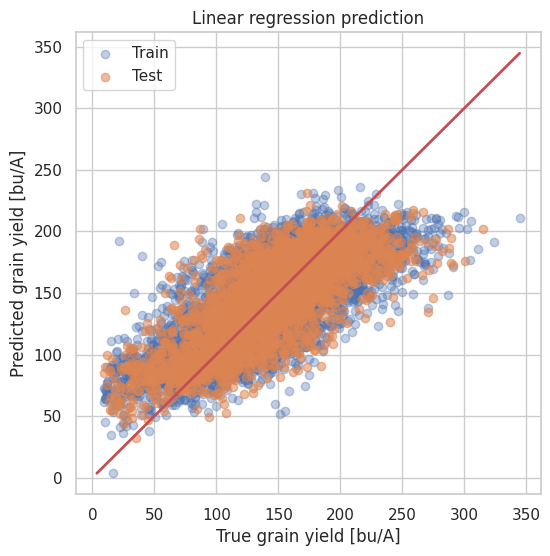

In [16]:
plt.figure(figsize=(6, 6))
plt.scatter(y_train, y_pred_train, alpha=0.35, label='Train')
plt.scatter(y_test, y_pred_test, alpha=0.55, label='Test')

xy_min = min(y.min(), y_pred_train.min(), y_pred_test.min())
xy_max = max(y.max(), y_pred_train.max(), y_pred_test.max())
plt.plot([xy_min, xy_max], [xy_min, xy_max], 'r-', linewidth=2)

plt.xlabel('True grain yield [bu/A]')
plt.ylabel('Predicted grain yield [bu/A]')
plt.title('Linear regression prediction')
plt.legend()
plt.grid(True)
plt.show()

## 9. 교차검증

train/test split은 한 번의 분할 결과에 영향을 받을 수 있다. 교차검증으로 평균적인 예측 성능을 확인한다.


In [17]:
NCV = 5
cv_scores = mod_sel.cross_val_score(
    regressor, X, y,
    scoring='neg_mean_squared_error',
    cv=NCV,
    n_jobs=1
)

cv_rmse = np.sqrt(-cv_scores)
print('CV RMSE scores:', cv_rmse)
print('Mean CV RMSE:', round(cv_rmse.mean(), 3))
print('Std CV RMSE:', round(cv_rmse.std(), 3))

CV RMSE scores: [32.22892206 31.2685222  32.41379342 30.25594793 52.32506713]
Mean CV RMSE: 35.698
Std CV RMSE: 8.349


CV R2: 0.366
CV RMSE: 36.661


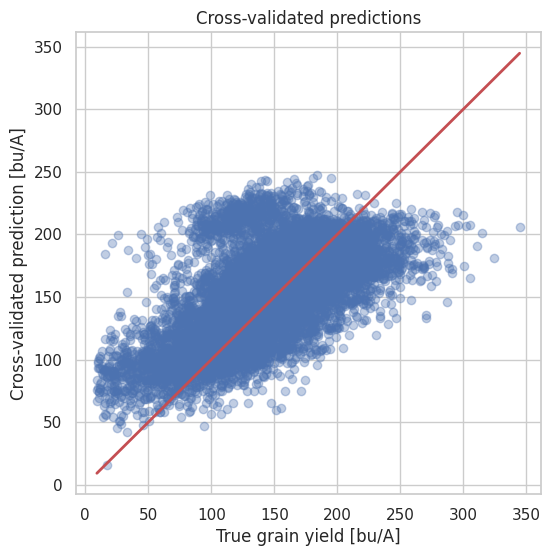

In [18]:
y_pred_cv = mod_sel.cross_val_predict(regressor, X, y, cv=NCV, n_jobs=1)

print('CV R2:', round(met.r2_score(y, y_pred_cv), 3))
print('CV RMSE:', round(math.sqrt(met.mean_squared_error(y, y_pred_cv)), 3))

plt.figure(figsize=(6, 6))
plt.scatter(y, y_pred_cv, alpha=0.35)
xy_min = min(y.min(), y_pred_cv.min())
xy_max = max(y.max(), y_pred_cv.max())
plt.plot([xy_min, xy_max], [xy_min, xy_max], 'r-', linewidth=2)
plt.xlabel('True grain yield [bu/A]')
plt.ylabel('Cross-validated prediction [bu/A]')
plt.title('Cross-validated predictions')
plt.grid(True)
plt.show()

## 10. GridSearchCV를 이용한 하이퍼파라미터 최적화

`LinearRegression`은 조정할 하이퍼파라미터가 많지 않다. 그래서 같은 선형모형 계열인 `Ridge`, `Lasso`, `ElasticNet`도 함께 비교한다.

- `Ridge`: 큰 회귀계수를 줄여 과적합을 완화하는 L2 regularization
- `Lasso`: 중요도가 낮은 feature 계수를 0에 가깝게 만드는 L1 regularization
- `ElasticNet`: Ridge와 Lasso를 섞은 regularization

작물 수량 예측에서는 예측값이 실제 수량의 순서를 얼마나 잘 따라가는지도 중요하므로, GridSearchCV의 최적화 기준은 PCC(Pearson correlation coefficient)로 둔다. RMSE, MAE, R²는 보조 지표로 함께 확인한다.


In [19]:
# GridSearchCV에서 비교할 모델과 하이퍼파라미터 후보.
# alpha가 클수록 regularization이 강해진다.
param_grid = [
    {
        'model': [lm.LinearRegression()],
        'model__fit_intercept': [True, False],
    },
    {
        'model': [lm.Ridge(random_state=0)],
        'model__alpha': [0.01, 0.1, 1, 10, 100],
        'model__fit_intercept': [True, False],
    },
    {
        'model': [lm.Lasso(max_iter=100000, tol=1e-3, random_state=0)],
        'model__alpha': [0.001, 0.01, 0.1, 1, 10],
        'model__fit_intercept': [True, False],
    },
    {
        'model': [lm.ElasticNet(max_iter=100000, tol=1e-3, random_state=0)],
        'model__alpha': [0.001, 0.01, 0.1, 1, 10],
        'model__l1_ratio': [0.1, 0.5, 0.9],
        'model__fit_intercept': [True, False],
    },
]

# 기존 regressor와 같은 preprocess를 사용하고, model step만 GridSearch에서 교체한다.
grid_base = Pipeline(steps=[
    ('preprocess', preprocessor),
    ('model', lm.LinearRegression()),
])

pcc_scorer = met.make_scorer(pearson_corr)

grid_search = mod_sel.GridSearchCV(
    estimator=grid_base,
    param_grid=param_grid,
    scoring={
        'pcc': pcc_scorer,
        'rmse': 'neg_root_mean_squared_error',
        'r2': 'r2',
    },
    refit='pcc',
    cv=5,
    n_jobs=-1,
    return_train_score=True,
)

grid_search.fit(X_train, y_train)

best_idx = grid_search.best_index_
print('Best CV PCC:', round(grid_search.best_score_, 3))
print('Best CV RMSE:', round(-grid_search.cv_results_['mean_test_rmse'][best_idx], 3))
print('Best parameters:')
for key, value in grid_search.best_params_.items():
    print(f'  {key}: {value}')


Best CV PCC: 0.755
Best CV RMSE: 30.167
Best parameters:
  model: Ridge(random_state=0)
  model__alpha: 1
  model__fit_intercept: True


### 10.1 후보 파라미터별 교차검증 성능 확인

아래 표는 GridSearchCV가 시도한 모든 조합을 CV PCC 기준으로 정렬한 결과다. `rank_test_pcc`가 1이면 교차검증에서 가장 좋은 조합이다. PCC는 클수록 좋고, RMSE는 작을수록 좋다.


In [20]:
def model_name_from_params(params):
    return params['model'].__class__.__name__

cv_results = pd.DataFrame(grid_search.cv_results_).copy()
cv_results['model_name'] = cv_results['params'].apply(model_name_from_params)
cv_results['mean_cv_pcc'] = cv_results['mean_test_pcc']
cv_results['std_cv_pcc'] = cv_results['std_test_pcc']
cv_results['mean_cv_rmse'] = -cv_results['mean_test_rmse']
cv_results['std_cv_rmse'] = cv_results['std_test_rmse']
cv_results['mean_train_pcc'] = cv_results['mean_train_pcc']
cv_results['mean_train_rmse'] = -cv_results['mean_train_rmse']
cv_results['alpha'] = cv_results['param_model__alpha'].astype(object)
cv_results['l1_ratio'] = cv_results['param_model__l1_ratio'].astype(object)
cv_results['fit_intercept'] = cv_results['param_model__fit_intercept'].astype(object)

result_cols = [
    'rank_test_pcc',
    'model_name',
    'alpha',
    'l1_ratio',
    'fit_intercept',
    'mean_cv_pcc',
    'std_cv_pcc',
    'mean_cv_rmse',
    'std_cv_rmse',
    'mean_train_pcc',
    'mean_train_rmse',
]

cv_results_sorted = cv_results.sort_values('rank_test_pcc')[result_cols]
display(cv_results_sorted.head(20))


,rank_test_pcc,model_name,alpha,l1_ratio,fit_intercept,mean_cv_pcc,std_cv_pcc,mean_cv_rmse,std_cv_rmse,mean_train_pcc,mean_train_rmse
6,1,Ridge,1.0,NaN,True,0.754886,0.007464,30.166936,0.697462,0.757663,30.017883
7,1,Ridge,1.0,NaN,False,0.754886,0.007464,30.166943,0.697561,0.757663,30.017891
24,3,ElasticNet,0.001,0.9,True,0.754885,0.007490,30.167006,0.696041,0.757668,30.017602
27,4,ElasticNet,0.001,0.9,False,0.754885,0.007490,30.167030,0.696125,0.757668,30.017605
4,5,Ridge,0.1,NaN,True,0.754882,0.007612,30.167159,0.689066,0.757682,30.016852
5,6,Ridge,0.1,NaN,False,0.754882,0.007612,30.167159,0.689077,0.757682,30.016853
12,7,Lasso,0.001,NaN,True,0.754880,0.007600,30.167267,0.689774,0.757681,30.016882
3,8,Ridge,0.01,NaN,False,0.754880,0.007628,30.167281,0.688147,0.757682,30.016841
2,9,Ridge,0.01,NaN,True,0.754880,0.007628,30.167281,0.688146,0.757682,30.016841
13,10,Lasso,0.001,NaN,False,0.754880,0.007597,30.167271,0.689936,0.757681,30.016887


### 10.2 모델별 최고 성능 비교

각 모델 계열에서 가장 좋은 조합만 뽑아 비교한다.


,rank_test_pcc,model_name,alpha,l1_ratio,fit_intercept,mean_cv_pcc,std_cv_pcc,mean_cv_rmse,std_cv_rmse,mean_train_pcc,mean_train_rmse
3,1,Ridge,1.0,None,True,0.754886,0.007464,30.166936,0.697462,0.757663,30.017883
0,3,ElasticNet,0.001,0.9,True,0.754885,0.007490,30.167006,0.696041,0.757668,30.017602
1,7,Lasso,0.001,None,True,0.754880,0.007600,30.167267,0.689774,0.757681,30.016882
2,11,LinearRegression,None,None,False,0.754880,0.007630,30.167296,0.688043,0.757682,30.016841


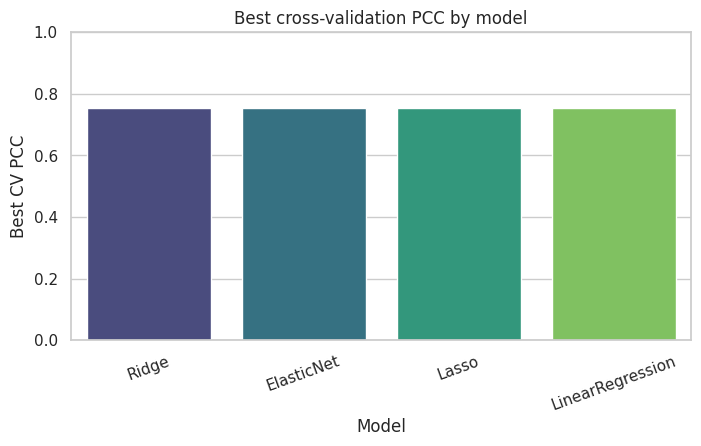

In [21]:
best_by_model = (
    cv_results
    .sort_values('mean_cv_pcc', ascending=False)
    .groupby('model_name', as_index=False)
    .first()
    [result_cols]
    .sort_values('mean_cv_pcc', ascending=False)
)

display(best_by_model)

plt.figure(figsize=(8, 4))
sns.barplot(data=best_by_model, x='model_name', y='mean_cv_pcc', hue='model_name', palette='viridis', legend=False)
plt.xlabel('Model')
plt.ylabel('Best CV PCC')
plt.title('Best cross-validation PCC by model')
plt.xticks(rotation=20)
plt.ylim(0, max(1.0, best_by_model['mean_cv_pcc'].max() + 0.05))
plt.grid(True, axis='y')
plt.show()


### 10.3 `alpha` 값에 따른 성능 변화

Regularization 모델에서 `alpha` 값이 커질수록 계수가 더 강하게 줄어든다. 아래 그림으로 `alpha` 변화에 따른 CV PCC를 확인한다. PCC는 값이 클수록 실제 수량과 예측 수량의 선형 관계가 강하다는 뜻이다.


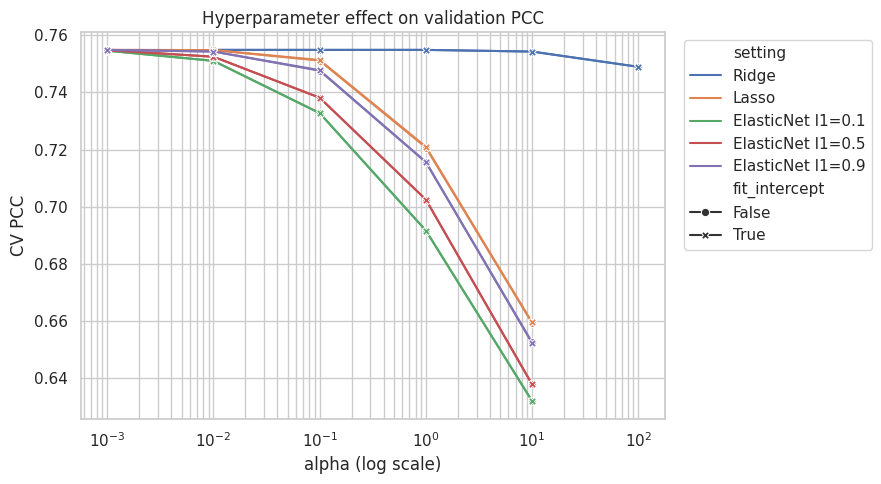

In [22]:
alpha_results = cv_results[cv_results['model_name'].isin(['Ridge', 'Lasso', 'ElasticNet'])].copy()
alpha_results['alpha_float'] = alpha_results['alpha'].astype(float)
alpha_results['setting'] = alpha_results.apply(
    lambda row: row['model_name'] if pd.isna(row['l1_ratio']) else f"{row['model_name']} l1={row['l1_ratio']}",
    axis=1,
)

plt.figure(figsize=(9, 5))
sns.lineplot(
    data=alpha_results,
    x='alpha_float',
    y='mean_cv_pcc',
    hue='setting',
    style='fit_intercept',
    markers=True,
    dashes=False,
)
plt.xscale('log')
plt.xlabel('alpha (log scale)')
plt.ylabel('CV PCC')
plt.title('Hyperparameter effect on validation PCC')
plt.grid(True, which='both', axis='both')
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()


### 10.4 최적 모델의 test set 성능 평가

GridSearchCV는 train set 내부의 교차검증으로 최적 조합을 고른다. 마지막에는 한 번도 최적화에 쓰지 않은 test set에서 성능을 확인한다.


,dataset,RMSE,MAE,R2,PCC
0,baseline train,30.033942,23.114571,0.573671,0.757411
1,baseline test,29.749093,22.733900,0.583415,0.763871
2,grid best train,30.034621,23.111745,0.573652,0.757399
3,grid best test,29.752506,22.738734,0.583319,0.763816


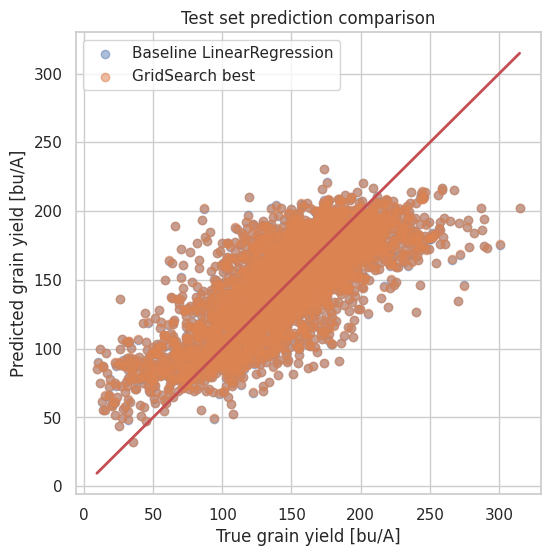

In [23]:
best_regressor = grid_search.best_estimator_

y_pred_train_best = best_regressor.predict(X_train)
y_pred_test_best = best_regressor.predict(X_test)

comparison_result = pd.DataFrame([
    regression_report(y_train, y_pred_train, 'baseline train'),
    regression_report(y_test, y_pred_test, 'baseline test'),
    regression_report(y_train, y_pred_train_best, 'grid best train'),
    regression_report(y_test, y_pred_test_best, 'grid best test'),
])

display(comparison_result)

plt.figure(figsize=(6, 6))
plt.scatter(y_test, y_pred_test, alpha=0.45, label='Baseline LinearRegression')
plt.scatter(y_test, y_pred_test_best, alpha=0.55, label='GridSearch best')
xy_min = min(y_test.min(), y_pred_test.min(), y_pred_test_best.min())
xy_max = max(y_test.max(), y_pred_test.max(), y_pred_test_best.max())
plt.plot([xy_min, xy_max], [xy_min, xy_max], 'r-', linewidth=2)
plt.xlabel('True grain yield [bu/A]')
plt.ylabel('Predicted grain yield [bu/A]')
plt.title('Test set prediction comparison')
plt.legend()
plt.grid(True)
plt.show()


### 10.5 최적 모델 다시 교차검증하기

최적 모델을 전체 데이터 기준으로 다시 교차검증해 baseline CV 결과와 비교한다. 여기서도 PCC를 주 비교 지표로 보고, RMSE를 함께 확인한다.


In [24]:
best_cv_scores = mod_sel.cross_validate(
    best_regressor,
    X,
    y,
    scoring={
        'pcc': pcc_scorer,
        'rmse': 'neg_root_mean_squared_error',
    },
    cv=NCV,
    n_jobs=1,
)

best_cv_pcc = best_cv_scores['test_pcc']
best_cv_rmse = -best_cv_scores['test_rmse']

baseline_cv_pcc = mod_sel.cross_val_score(
    regressor,
    X,
    y,
    scoring=pcc_scorer,
    cv=NCV,
    n_jobs=1,
)

print('Baseline CV PCC mean:', round(baseline_cv_pcc.mean(), 3))
print('Baseline CV PCC std :', round(baseline_cv_pcc.std(), 3))
print('Baseline CV RMSE mean:', round(cv_rmse.mean(), 3))
print('Baseline CV RMSE std :', round(cv_rmse.std(), 3))
print('Grid best CV PCC mean:', round(best_cv_pcc.mean(), 3))
print('Grid best CV PCC std :', round(best_cv_pcc.std(), 3))
print('Grid best CV RMSE mean:', round(best_cv_rmse.mean(), 3))
print('Grid best CV RMSE std :', round(best_cv_rmse.std(), 3))


Baseline CV PCC mean: 0.618
Baseline CV PCC std : 0.081
Baseline CV RMSE mean: 35.698
Baseline CV RMSE std : 8.349
Grid best CV PCC mean: 0.616
Grid best CV PCC std : 0.086
Grid best CV RMSE mean: 36.01
Grid best CV RMSE std : 9.031


## 11. 회귀계수 확인

GridSearchCV로 선택한 최적 선형모형의 회귀계수를 확인한다. one-hot encoding 이후 feature 수가 많아진다. 아래 코드는 절대값이 큰 계수를 확인한다. 단, one-hot feature와 scaling된 numeric feature가 섞여 있으므로 해석에는 주의가 필요하다.


In [25]:
def get_transformed_feature_names(fitted_pipeline):
    fitted_preprocessor = fitted_pipeline.named_steps['preprocess']
    names = []

    # Numeric features keep their original names.
    names.extend(numeric_features)

    # Compatibility with older and newer scikit-learn versions.
    fitted_onehot = fitted_preprocessor.named_transformers_['cat'].named_steps['onehot']
    if hasattr(fitted_onehot, 'get_feature_names_out'):
        cat_names = fitted_onehot.get_feature_names_out(categorical_features)
    else:
        cat_names = fitted_onehot.get_feature_names(categorical_features)
    names.extend(list(cat_names))
    return np.array(names)

coef_pipeline = best_regressor
coef_model = coef_pipeline.named_steps['model']
feature_names = get_transformed_feature_names(coef_pipeline)
coef = coef_model.coef_

coef_df = pd.DataFrame({
    'feature': feature_names,
    'coef': coef,
    'abs_coef': np.abs(coef),
}).sort_values('abs_coef', ascending=False)

print('Coefficient model:', coef_model)
display(coef_df.head(20))


Coefficient model: Ridge(alpha=1, random_state=0)


,feature,coef,abs_coef
4,Plot Length Field,49.766007,49.766007
7,Plot Area,-44.184999,44.184999
5,Alley Length,-32.615272,32.615272
23,weather_rh_mean,31.835495,31.835495
21,weather_temp_min,24.719912,24.719912
19,weather_temp_mean,-22.334189,22.334189
25,weather_wind_mean,21.118038,21.118038
14,Plant Height [cm],19.669897,19.669897
6,Row Spacing,18.530936,18.530936
16,Stand Count [plants],15.827543,15.827543


## 12. 실습 과제
1. `Field-Location`을 feature에 추가하고 모델을 다시 학습해 보자. 교차검증 성능과 예측 안정성이 어떻게 변하는가?
2. `Pedigree`와 `Source`를 feature에 추가하고 모델을 다시 학습해 보자. 범주가 많은 변수를 one-hot encoding하면 어떤 문제가 생길 수 있는가?
3. `Grain Moisture [%]`, `Test Weight [lbs/bu]`를 feature에 추가하면 성능이 어떻게 변하는가? 이 feature들이 target leakage일 가능성은 없는가?
4. location을 기준으로 train/test를 나누면 성능이 어떻게 변하는가?
5. `weather` feature 없이 학습한 모델과 `weather` feature를 포함한 모델을 비교해 보자.
6. LinearRegression 대신 Ridge, Lasso, ElasticNet 같은 regularized linear model을 사용하면 어떤 점이 좋아지는지 확인하라.


## 13. SHAP 분석
SHAP(SHapley Additive exPlanations)은 각 feature가 개별 예측값을 얼마나 증가 또는 감소시켰는지 설명하는 방법이다. 여기서는 학습된 `LinearRegression` 모델과 전처리된 feature matrix를 사용하여 SHAP 값을 계산한다.
`shap` 패키지가 설치되어 있지 않으면 아래 안내 메시지가 출력된다. 필요한 경우 다음 명령을 별도 셀에서 실행한 뒤 커널을 재시작한다.
```python
%pip install shap
```


In [26]:
try:
    import shap
    shap_available = True
    print('shap version:', shap.__version__)
except ModuleNotFoundError:
    shap_available = False
    print('SHAP is not installed.')
    print('Run this in a new cell if you want to install it: %pip install shap')

SHAP is not installed.
Run this in a new cell if you want to install it: %pip install shap


### 13.1 SHAP 입력 데이터 준비
모델은 `Pipeline` 안에서 전처리를 수행하므로, SHAP에는 전처리가 끝난 numeric matrix를 넣는다. 데이터가 너무 크면 계산과 그림 출력이 느릴 수 있어 test set 일부만 사용한다.


In [27]:
if shap_available:
    fitted_preprocessor = regressor.named_steps['preprocess']
    fitted_model = regressor.named_steps['model']

    X_train_processed = fitted_preprocessor.transform(X_train)
    X_test_processed = fitted_preprocessor.transform(X_test)

    # Some encoders can return sparse matrices depending on scikit-learn version.
    if hasattr(X_train_processed, 'toarray'):
        X_train_processed = X_train_processed.toarray()
    if hasattr(X_test_processed, 'toarray'):
        X_test_processed = X_test_processed.toarray()

    feature_names = get_transformed_feature_names(regressor)

    background_size = min(200, X_train_processed.shape[0])
    explain_size = min(500, X_test_processed.shape[0])

    rng = np.random.default_rng(0)
    background_idx = rng.choice(X_train_processed.shape[0], size=background_size, replace=False)

    X_background_shap = pd.DataFrame(
        X_train_processed[background_idx],
        columns=feature_names,
    )
    X_test_shap = pd.DataFrame(
        X_test_processed[:explain_size],
        columns=feature_names,
    )

    print('background data:', X_background_shap.shape)
    print('explain data:', X_test_shap.shape)
else:
    print('Skipped: SHAP is not installed.')

Skipped: SHAP is not installed.


### 13.2 SHAP value 계산
선형모형에서는 각 feature의 값과 회귀계수가 예측값에 기여한다. SHAP은 이 기여도를 feature별로 분해해서 보여준다.


In [28]:
if shap_available:
    explainer = shap.LinearExplainer(fitted_model, X_background_shap)
    shap_values = explainer(X_test_shap)

    print('SHAP values shape:', shap_values.values.shape)
    print('Base value:', np.mean(shap_values.base_values))
else:
    print('Skipped: SHAP is not installed.')

Skipped: SHAP is not installed.


### 13.3 Global interpretation
아래 bar plot은 전체 test sample에서 평균적으로 영향이 큰 feature를 보여준다. Beeswarm plot은 feature 값의 크기와 예측 영향 방향을 함께 보여준다.


In [29]:
if shap_available:
    shap.plots.bar(shap_values, max_display=20)
else:
    print('Skipped: SHAP is not installed.')

Skipped: SHAP is not installed.


In [30]:
if shap_available:
    shap.plots.beeswarm(shap_values, max_display=20)
else:
    print('Skipped: SHAP is not installed.')

Skipped: SHAP is not installed.


### 13.4 Local interpretation
아래 waterfall plot은 test sample 하나의 예측값이 base value에서 시작해 feature별 영향으로 어떻게 변하는지 보여준다.


In [31]:
if shap_available:
    sample_id = 0
    print('True yield:', y_test.iloc[sample_id])
    print('Predicted yield:', y_pred_test[sample_id])
    shap.plots.waterfall(shap_values[sample_id], max_display=15)
else:
    print('Skipped: SHAP is not installed.')

Skipped: SHAP is not installed.


### 13.5 선형모형 계수와 SHAP 비교
선형회귀에서 회귀계수는 feature의 방향성을 보여주고, SHAP 값은 실제 sample 분포에서 그 feature가 예측에 얼마나 기여했는지를 보여준다. 따라서 계수의 절대값 순위와 SHAP 중요도 순위는 비슷할 수도 있지만 항상 같지는 않다.


In [32]:
if shap_available:
    shap_importance = pd.DataFrame({
        'feature': feature_names,
        'mean_abs_shap': np.abs(shap_values.values).mean(axis=0),
        'coef': fitted_model.coef_,
    }).sort_values('mean_abs_shap', ascending=False)

    display(shap_importance.head(20))
else:
    print('Skipped: SHAP is not installed.')

Skipped: SHAP is not installed.
